In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

# load the dataset
df = pd.read_csv("/content/drive/MyDrive/AIML-project/diabetes_data_pre_processed_final.csv")

# 2. Define Features (X) and Target (y)
feature_cols = [
    'gender', 'hypertension', 'heart_disease', 'smoking_history',
    'age_std', 'bmi_std', 'HbA1c_level_std', 'blood_glucose_level_std',
    'age_group_Adult', 'age_group_Middle-aged', 'age_group_Senior', 'age_group_Young'
]

X = df[feature_cols]
y = df['diabetes']

# Convert categorical features to appropriate numeric types if needed (optional step, but good practice)
X['smoking_history'] = X['smoking_history'].astype(int)

# --- 3. Split the Data ---
# We use a standard 80/20 train-test split for validation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Get input shape for the model architecture
input_shape = X_train.shape[1]
print(f"Input Shape (Number of Features): {input_shape}")

Input Shape (Number of Features): 12


/tmp/ipython-input-3746835661.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['smoking_history'] = X['smoking_history'].astype(int)


In [19]:
# --- 4. Define MLP Model Builder Function ---
def build_mlp_model(input_dim, layers, dropout_rate=0.0, optimizer='adam', activation='relu'):
    """Builds a sequential MLP model for binary classification."""
    model = Sequential()

    # Add hidden layers with specified number of neurons and activation
    for i, units in enumerate(layers):
        if i == 0:
            model.add(Dense(units, activation=activation, input_shape=(input_dim,)))
        else:
            model.add(Dense(units, activation=activation))

        # Add Dropout layer for regularization
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))

    # Output layer for binary classification (1 neuron, sigmoid activation)
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', AUC(name='auc')]
    )
    return model


--- Training Model Variety 1: Baseline MLP ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline MLP - Test Accuracy: 0.9103
Baseline MLP - Test AUC: 0.9755
Baseline MLP - Test F1 Score (Weighted): 0.9102
Baseline MLP - Confusion Matrix:
[[15126  2053]
 [ 1028 16150]]


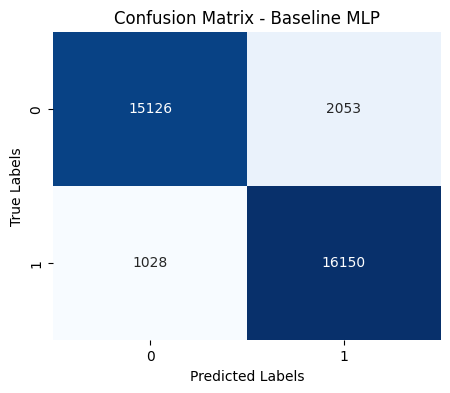

In [20]:
# --- 5. Variety 1: Baseline MLP (Shallow, Standard) ---

print("\n--- Training Model Variety 1: Baseline MLP ---")
mlp_baseline = build_mlp_model(
    input_dim=input_shape,
    layers=[64, 32],
    dropout_rate=0.0,
    optimizer=keras.optimizers.Adam(learning_rate=0.001)
)

history_baseline = mlp_baseline.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,  # Use 10% of training data for validation during training
    verbose=0
)

# Evaluate Baseline Model
loss_b, accuracy_b, auc_b = mlp_baseline.evaluate(X_test, y_test, verbose=0)
y_pred_proba_b = mlp_baseline.predict(X_test, verbose=0)
y_pred_b = (y_pred_proba_b > 0.5).astype("int32")

# Calculate metrics
f1_b = classification_report(y_test, y_pred_b, output_dict=True)['weighted avg']['f1-score']
conf_matrix_b = confusion_matrix(y_test, y_pred_b)

print(f"Baseline MLP - Test Accuracy: {accuracy_b:.4f}")
print(f"Baseline MLP - Test AUC: {auc_b:.4f}")
print(f"Baseline MLP - Test F1 Score (Weighted): {f1_b:.4f}")
print(f"Baseline MLP - Confusion Matrix:\n{conf_matrix_b}")

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix_b, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Baseline MLP")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()



--- Training Model Variety 2: Tuned MLP ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Tuned MLP - Test Accuracy: 0.9044
Tuned MLP - Test AUC: 0.9718
Tuned MLP - Test F1 Score (Weighted): 0.9043


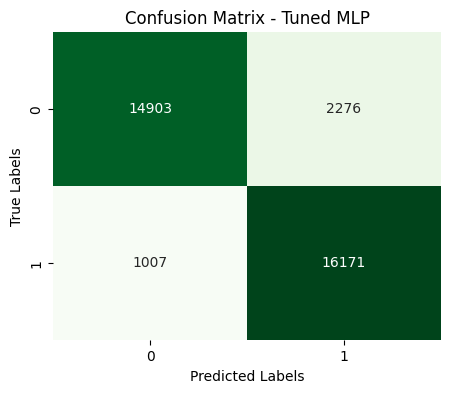

In [21]:
# --- 6. Variety 2: Tuned MLP (Deeper, Regularized) ---

print("\n--- Training Model Variety 2: Tuned MLP ---")
mlp_tuned = build_mlp_model(
    input_dim=input_shape,
    layers=[128, 64, 32],  # Deeper architecture
    dropout_rate=0.2,       # Added Dropout regularization
    optimizer=keras.optimizers.RMSprop(learning_rate=0.0005) # Different optimizer and lower LR
)

history_tuned = mlp_tuned.fit(
    X_train,
    y_train,
    epochs=50, # Longer training time to accommodate more layers/lower LR
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

# Evaluate Tuned Model
loss_t, accuracy_t, auc_t = mlp_tuned.evaluate(X_test, y_test, verbose=0)
y_pred_proba_t = mlp_tuned.predict(X_test, verbose=0)
y_pred_t = (y_pred_proba_t > 0.5).astype("int32")

# Calculate metrics
f1_t = classification_report(y_test, y_pred_t, output_dict=True)['weighted avg']['f1-score']
conf_matrix_t = confusion_matrix(y_test, y_pred_t)

print(f"Tuned MLP - Test Accuracy: {accuracy_t:.4f}")
print(f"Tuned MLP - Test AUC: {auc_t:.4f}")
print(f"Tuned MLP - Test F1 Score (Weighted): {f1_t:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix_t, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix - Tuned MLP")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

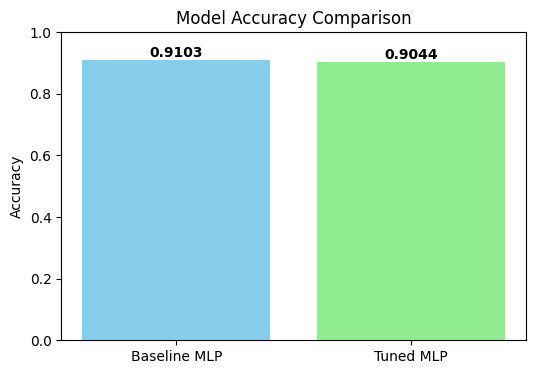

In [22]:
# --- Accuracy Comparison Chart ---
import matplotlib.pyplot as plt

models = ['Baseline MLP', 'Tuned MLP']
accuracies = [accuracy_b, accuracy_t]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()
